In [3]:
import sys
import os
import pandas as pd
# Add the project root (the folder containing both ml_analysis and manage_db)
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(project_root)

from manage_db.db_manager_v1 import DbManagerV1

In [4]:
db = DbManagerV1("jp_realestate_v1")
df = db.load_data(include_expired=True)


In [5]:
df

,id,source,scraped_at,status,last_update,price_yen,source_listing_id,available_from,balcony_size,building_area_ratio,...,size,structure,total_floors,transaction_type,type,unit_floor,unit_number,unit_summary,year_built,zoning
0,1,realestate.co,2025-12-09 14:06:55.819278+00:00,expired,2026-05-12 10:18:59.472245+00:00,85000000,1263339,2025-08-05,NaN,70.0,...,98.33,Wood,NaN,Non-Exclusive,Hotel/Ryokan,NaN,NaN,NaN,NaN,Residential
1,2,realestate.co,2025-12-09 14:06:55.819278+00:00,expired,2026-05-12 10:18:58.813915+00:00,32200000,1246678,2025-06-25,NaN,NaN,...,19.16,Steel Reinforced Concrete,12.0,Non-Exclusive,Mansion,10.0,10,NaN,NaN,Commercial
2,3,realestate.co,2025-12-09 14:06:55.819278+00:00,active,2026-05-23 08:23:52.897569+00:00,64900000,1269523,2025-08-25,3.21,NaN,...,36.30,Steel Reinforced Concrete,14.0,Non-Exclusive,Mansion,2.0,206,NaN,NaN,Residential / Commercial
3,8,realestate.co,2025-12-09 14:06:55.819278+00:00,expired,2025-12-09 14:06:55.819278+00:00,155000000,1212519,2025-03-21,5.13,NaN,...,70.19,Reinforced Concrete,10.0,Non-Exclusive,Mansion,2.0,NaN,NaN,NaN,Residential / Commercial
4,9,realestate.co,2025-12-09 14:06:55.819278+00:00,expired,2025-12-09 14:06:55.819278+00:00,89800000,1215850,NaN,9.21,NaN,...,50.52,Steel Reinforced Concrete,13.0,Non-Exclusive,Mansion,9.0,9,NaN,NaN,Commercial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5606,5768,realestate.co,2025-12-03 10:23:40.582274+00:00,expired,2025-12-03 10:23:40.582274+00:00,284900000,1292126,NaN,13.16,NaN,...,65.09,Reinforced Concrete,10.0,Brokerage,Mansion,2.0,NaN,NaN,NaN,NaN
5607,5769,realestate.co,2025-12-03 10:23:40.582274+00:00,active,2025-12-03 10:23:40.582274+00:00,348000000,1279517,NaN,8.36,NaN,...,80.96,Reinforced Concrete,8.0,Brokerage,Mansion,2.0,NaN,NaN,NaN,NaN
5608,5770,realestate.co,2025-12-09 14:08:38.958663+00:00,active,2025-12-09 14:08:38.958663+00:00,360000000,1294774,NaN,NaN,NaN,...,136.35,Reinforced Concrete,NaN,Brokerage,House,NaN,NaN,NaN,2013.0,NaN
5609,5771,realestate.co,2025-12-03 10:18:30.580965+00:00,active,2025-12-03 10:18:30.580965+00:00,98000000,1297289,2025-11-15,NaN,50.0,...,148.76,Light Gauge Steel,2.0,Non-Exclusive,House,NaN,NaN,NaN,NaN,Residential


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5611 entries, 0 to 5610
Data columns (total 50 columns):
 #   Column                  Non-Null Count  Dtype              
---  ------                  --------------  -----              
 0   id                      5611 non-null   int64              
 1   source                  5611 non-null   object             
 2   scraped_at              5611 non-null   datetime64[ns, UTC]
 3   status                  5611 non-null   object             
 4   last_update             5611 non-null   datetime64[ns, UTC]
 5   price_yen               5611 non-null   int64              
 6   source_listing_id       5611 non-null   object             
 7   available_from          2252 non-null   object             
 8   balcony_size            2354 non-null   float64            
 9   building_area_ratio     1588 non-null   float64            
 10  building_description    4888 non-null   object             
 11  building_name           5592 non-null   obj

In [7]:
df['type'].value_counts()

type
Mansion          3638
House            1530
Hotel/Ryokan      182
Retail             38
Apartment          30
Holiday House      21
Office             19
Terrace house       5
Other               3
Town house          3
Warehouse           1
Name: count, dtype: int64

In [8]:
df.groupby("type")['price_yen'].agg(["count","min","max"])

,count,min,max
type,,,
Apartment,30,12800000,482000000
Holiday House,21,4000000,440000000
Hotel/Ryokan,182,11000000,7500000000
House,1530,600000,1850000000
Mansion,3638,1390000,5500000000
Office,19,27900000,1720000000
Other,3,64800000,400000000
Retail,38,13500000,2200000000
Terrace house,5,14800000,79800000


In [9]:
df.groupby("type")['price_yen'].median()

type
Apartment        106150000.0
Holiday House     52010000.0
Hotel/Ryokan     147629500.0
House             45990000.0
Mansion           81800000.0
Office           430000000.0
Other            180000000.0
Retail            97400000.0
Terrace house     64600000.0
Town house        89800000.0
Warehouse         37000000.0
Name: price_yen, dtype: float64

In [10]:
df.groupby("type")["price_yen"].quantile([0.25,0.5,0.75,0.9,0.99])

type               
Apartment      0.25    4.656891e+07
               0.50    1.061500e+08
               0.75    1.755000e+08
               0.90    2.135000e+08
               0.99    4.489400e+08
Holiday House  0.25    6.500000e+06
               0.50    5.201000e+07
               0.75    9.800000e+07
               0.90    4.100000e+08
               0.99    4.340000e+08
Hotel/Ryokan   0.25    7.500000e+07
               0.50    1.476295e+08
               0.75    2.800000e+08
               0.90    4.500000e+08
               0.99    1.081080e+09
House          0.25    1.880000e+07
               0.50    4.599000e+07
               0.75    9.367500e+07
               0.90    1.780000e+08
               0.99    5.436200e+08
Mansion        0.25    3.680000e+07
               0.50    8.180000e+07
               0.75    1.599000e+08
               0.90    2.980000e+08
               0.99    1.080000e+09
Office         0.25    1.290000e+08
               0.50    4.300000e+08
        

In [11]:
df[["city","prefecture","district"]]

,city,prefecture,district
0,Edogawa-ku,Tokyo,Kitakoiwa
1,Minato-ku,Tokyo,Azabujuban
2,Shinjuku-ku,Tokyo,Arakicho
3,Shibuya-ku,Tokyo,Tomigaya
4,Shibuya-ku,Tokyo,Udagawacho
...,...,...,...
5606,Minato-ku,Tokyo,Azabumamianacho
5607,Minato-ku,Tokyo,Minamiazabu
5608,Minato-ku,Tokyo,Nishiazabu
5609,Nagoya-shi Showa-ku,Aichi,Nishibatacho


In [12]:
df["price_yen"].min(),df["price_yen"].max()

(np.int64(600000), np.int64(7500000000))

## Data preprocessing

In [13]:
df = df.drop(columns=[
"id",
"source",
"scraped_at",
"status",
"last_update",
"source_listing_id",
"building_description",
"building_name",
"date_updated",
"unit_number",
"unit_summary",
"next_update_schedule"])

df = df.drop(columns = [
"investment_situation",
"road_width",
"sell_situation",
"landmarks",
"manager_style",
"manage_type"])


In [14]:
df

,price_yen,available_from,balcony_size,building_area_ratio,city,construction_completed,direction_facing,district,floor_area_ratio,gross_yield,...,prefecture,repair_reserve_fund,size,structure,total_floors,transaction_type,type,unit_floor,year_built,zoning
0,85000000,2025-08-05,NaN,70.0,Edogawa-ku,2023.0,"North, East",Kitakoiwa,300.0,12.5,...,Tokyo,NaN,98.33,Wood,NaN,Non-Exclusive,Hotel/Ryokan,NaN,NaN,Residential
1,32200000,2025-06-25,NaN,NaN,Minato-ku,2001.0,South,Azabujuban,NaN,NaN,...,Tokyo,5550.0,19.16,Steel Reinforced Concrete,12.0,Non-Exclusive,Mansion,10.0,NaN,Commercial
2,64900000,2025-08-25,3.21,NaN,Shinjuku-ku,1997.0,South,Arakicho,NaN,NaN,...,Tokyo,10160.0,36.30,Steel Reinforced Concrete,14.0,Non-Exclusive,Mansion,2.0,NaN,Residential / Commercial
3,155000000,2025-03-21,5.13,NaN,Shibuya-ku,2021.0,West,Tomigaya,NaN,NaN,...,Tokyo,8400.0,70.19,Reinforced Concrete,10.0,Non-Exclusive,Mansion,2.0,NaN,Residential / Commercial
4,89800000,NaN,9.21,NaN,Shibuya-ku,1978.0,Northeast,Udagawacho,NaN,NaN,...,Tokyo,8440.0,50.52,Steel Reinforced Concrete,13.0,Non-Exclusive,Mansion,9.0,NaN,Commercial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5606,284900000,NaN,13.16,NaN,Minato-ku,2013.0,South,Azabumamianacho,NaN,NaN,...,Tokyo,8010.0,65.09,Reinforced Concrete,10.0,Brokerage,Mansion,2.0,NaN,NaN
5607,348000000,NaN,8.36,NaN,Minato-ku,2014.0,NaN,Minamiazabu,NaN,NaN,...,Tokyo,10370.0,80.96,Reinforced Concrete,8.0,Brokerage,Mansion,2.0,NaN,NaN
5608,360000000,NaN,NaN,NaN,Minato-ku,NaN,NaN,Nishiazabu,NaN,NaN,...,Tokyo,NaN,136.35,Reinforced Concrete,NaN,Brokerage,House,NaN,2013.0,NaN
5609,98000000,2025-11-15,NaN,50.0,Nagoya-shi Showa-ku,2010.0,South,Nishibatacho,100.0,NaN,...,Aichi,NaN,148.76,Light Gauge Steel,2.0,Non-Exclusive,House,NaN,NaN,Residential


In [15]:
import re
import numpy as np

def clean_layout(df):
    # standardize to string
    df["layout"] = df["layout"].fillna("").astype(str).str.strip()

    # 1. Flag whole-building listings
    df["is_whole_building"] = df["layout"].str.contains("whole", case=False).astype(int)

    # 2. Extract number of rooms (LDK style)
    # e.g. 1LDK, 3DK, 2K → extract leading digits
    df["rooms"] = df["layout"].str.extract(r"^(\d+)").astype(float)

    # 3. Detect layout characters (L, D, K)
    df["has_living"] = df["layout"].str.contains("L", case=False).astype(int)
    df["has_dining"] = df["layout"].str.contains("D", case=False).astype(int)
    df["has_kitchen"] = df["layout"].str.contains("K", case=False).astype(int)
    df["has_storage"] = df["layout"].str.contains(r"S(?!TUDIO)", case=False).astype(int)

    # 4. Studio / R-type detection (1R, R, SR)
    r_pattern = r"(^1R$)|(^R$)|(^SR$)|(\b1R\b)|(\bR\b)"
    is_r_type = df["layout"].str.contains(r_pattern, case=False)


    # 5. Fill missing rooms for whole buildings with NaN (can't infer)
    df.loc[df["is_whole_building"] == 1, "rooms"] = np.nan

    df = df.drop(columns = ["layout"])

    return df


In [16]:
df = clean_layout(df)

C:\Users\nox map\AppData\Local\Temp\ipykernel_8320\2178700966.py:23: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_r_type = df["layout"].str.contains(r_pattern, case=False)


In [17]:
df[["is_whole_building","rooms","has_living","has_dining","has_kitchen","has_storage"]]

,is_whole_building,rooms,has_living,has_dining,has_kitchen,has_storage
0,1,NaN,1,1,0,0
1,0,1.0,0,0,0,0
2,0,1.0,1,1,1,0
3,0,2.0,1,1,1,1
4,0,2.0,1,1,1,0
...,...,...,...,...,...,...
5606,0,2.0,1,1,1,0
5607,0,3.0,1,1,1,0
5608,0,3.0,1,1,1,0
5609,0,5.0,1,1,1,1


In [18]:
directions = [
    "North",
    "South",
    "East",
    "West"
]

for direction in directions:
    df[f"facing_{direction.lower()}"] = (
        df["direction_facing"]
        .fillna("")
        .str.contains(direction, regex=False)
        .astype(int)
    )

In [19]:
df[["facing_north","facing_south","facing_east","facing_west","direction_facing"]]

,facing_north,facing_south,facing_east,facing_west,direction_facing
0,1,0,1,0,"North, East"
1,0,1,0,0,South
2,0,1,0,0,South
3,0,0,0,1,West
4,1,0,0,0,Northeast
...,...,...,...,...,...
5606,0,1,0,0,South
5607,0,0,0,0,NaN
5608,0,0,0,0,NaN
5609,0,1,0,0,South


In [20]:
df = df.drop(columns=["direction_facing"])

In [21]:
df[["available_from","construction_completed"]]

,available_from,construction_completed
0,2025-08-05,2023.0
1,2025-06-25,2001.0
2,2025-08-25,1997.0
3,2025-03-21,2021.0
4,NaN,1978.0
...,...,...
5606,NaN,2013.0
5607,NaN,2014.0
5608,NaN,NaN
5609,2025-11-15,2010.0


In [22]:
from datetime import datetime

In [23]:
current_year = datetime.now().year
df["age"] = current_year - df['construction_completed']
df["age"]

0        3.0
1       25.0
2       29.0
3        5.0
4       48.0
        ... 
5606    13.0
5607    12.0
5608     NaN
5609    16.0
5610     NaN
Name: age, Length: 5611, dtype: float64

In [24]:
df = df.drop(columns=["construction_completed"])

In [25]:
df["available_from"] = pd.to_datetime(df["available_from"], errors='coerce')

In [26]:
# Days until available (NaN stays if missing)
df['days_until_available'] = (pd.Timestamp.today() - df['available_from']).dt.days

# Extract month and year for seasonality patterns
df['available_month'] = df['available_from'].dt.month
df['available_year'] = df['available_from'].dt.year

In [27]:
df[["days_until_available","available_month","available_year"]]

,days_until_available,available_month,available_year
0,303.0,8.0,2025.0
1,344.0,6.0,2025.0
2,283.0,8.0,2025.0
3,440.0,3.0,2025.0
4,NaN,NaN,NaN
...,...,...,...
5606,NaN,NaN,NaN
5607,NaN,NaN,NaN
5608,NaN,NaN,NaN
5609,201.0,11.0,2025.0


In [28]:
df = df.drop(columns=["available_from"])

In [29]:
df = df.drop(columns=["other_expenses"])

In [30]:
# Maybe handle gross_yeald(14% non Null) and aviable from(40% non Null) 's na values 

## Model testing 

In [31]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn import metrics
import numpy as np

In [32]:
TARGET = "price_yen"
RANDOM_STATE = 42
TEST_SIZE = 0.2 

In [33]:
y = df[TARGET].values
x = df.drop(columns=[TARGET])

In [34]:
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

In [35]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [36]:
import catboost

In [37]:
cat_features = [
    'city',
    'district',
    'land_rights',
    'ns_line',
    'ns_mode',
    'ns_name',
    'occupancy',
    'parking',
    'prefecture',
    'structure',
    'transaction_type',
    'type',
    'zoning'
]

In [38]:
for col in cat_features:
    x_train[col] = x_train[col].fillna("Unknown")
    x_test[col] = x_test[col].fillna("Unknown")

In [39]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4488 entries, 4323 to 860
Data columns (total 40 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   balcony_size           1876 non-null   float64
 1   building_area_ratio    1291 non-null   float64
 2   city                   4488 non-null   object 
 3   district               4488 non-null   object 
 4   floor_area_ratio       1321 non-null   float64
 5   gross_yield            659 non-null    float64
 6   land_area              1713 non-null   float64
 7   land_rights            4488 non-null   object 
 8   maintenance_fee        2877 non-null   float64
 9   ns_distance_min        4114 non-null   float64
 10  ns_line                4488 non-null   object 
 11  ns_mode                4488 non-null   object 
 12  ns_name                4488 non-null   object 
 13  occupancy              4488 non-null   object 
 14  parking                4488 non-null   object 
 15  potenti

In [40]:
model = catboost.CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    verbose=100
)

model.fit(
    x_train,
    y_train_log,
    cat_features=cat_features
)

0:	learn: 1.1947570	total: 243ms	remaining: 4m 2s
100:	learn: 0.4408896	total: 8.58s	remaining: 1m 16s
200:	learn: 0.3687530	total: 16.3s	remaining: 1m 4s
300:	learn: 0.3262334	total: 25.2s	remaining: 58.5s
400:	learn: 0.2974323	total: 32.7s	remaining: 48.9s
500:	learn: 0.2705058	total: 40.4s	remaining: 40.2s
600:	learn: 0.2517153	total: 47.7s	remaining: 31.6s
700:	learn: 0.2336062	total: 55.5s	remaining: 23.7s
800:	learn: 0.2179308	total: 1m 3s	remaining: 15.7s
900:	learn: 0.2044660	total: 1m 10s	remaining: 7.8s
999:	learn: 0.1921640	total: 1m 18s	remaining: 0us


CatBoostRegressor(depth=8, iterations=1000, learning_rate=0.05, loss_function='RMSE', verbose=100)

In [41]:
def evaluate1(model, X_val, y_val):
    y_pred = model.predict(X_val)

    # basic safety for log-based metrics
    y_pred = np.clip(y_pred, 0, None)

    r2 = metrics.r2_score(y_val, y_pred)
    mae = metrics.mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(metrics.mean_squared_error(y_val, y_pred))

    print("R2 :", r2)
    print("MAE:", mae)
    print("RMSE:", rmse)

    return {"r2": r2, "mae": mae, "rmse": rmse}

In [42]:
evaluate1(model,x_test,y_test_log)

R2 : 0.8959420217913857
MAE: 0.25409057550235997
RMSE: 0.3850445155971557


{'r2': 0.8959420217913857,
 'mae': 0.25409057550235997,
 'rmse': np.float64(0.3850445155971557)}

In [44]:
import shap

C:\Users\nox map\PycharmProjects\realestate_agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


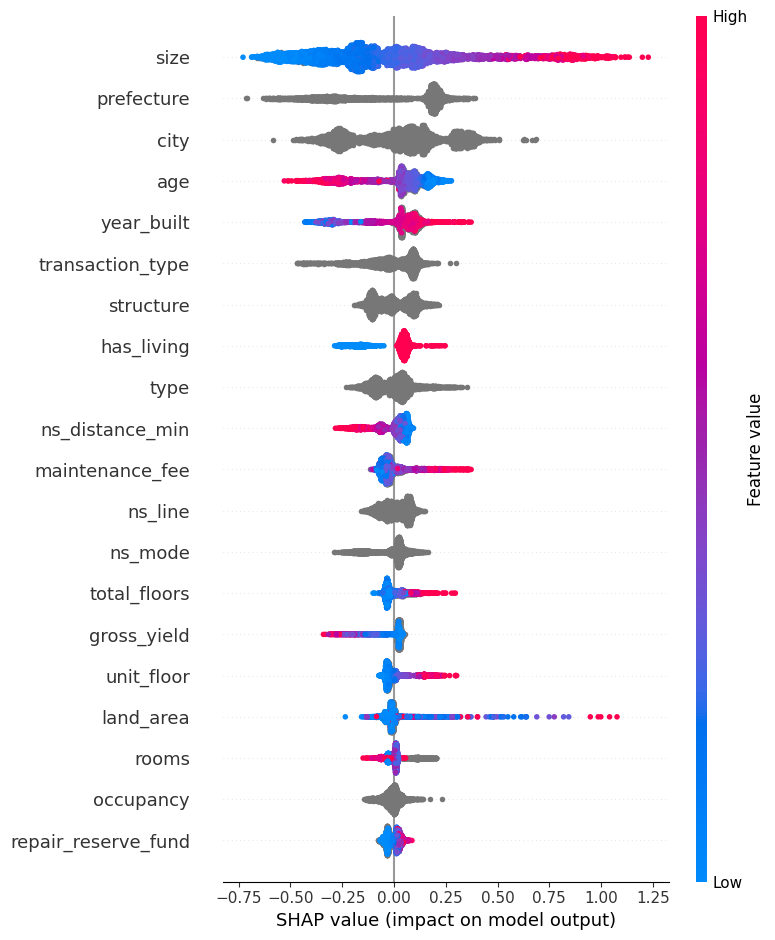

In [46]:
explaner = shap.TreeExplainer(model)
shap_values = explaner.shap_values(x_train)
shap.summary_plot(shap_values, x_train)